# Split-Hygiene Audit (CLASSIFIER)

**Hard-fails** with `AssertionError` if any of the following is wrong:

1. **Subject-overlap** — a single `Pseudonym` is found in more than one of the train/val/test split CSVs.
2. **Duplicate matrices** — two distinct `.npz` files contain the exact same array (upstream preprocessing bug).
3. **StratifiedGroupKFold** — re-running CV with the saved seed produces overlapping validation folds.
4. **GAAE ↔ downstream cohort policy** — the chosen policy (`shared` or `disjoint`) is asserted.

Wire this notebook's checks into every production notebook via `from common.sanity import run_full_audit`.

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
# Safe interactive defaults: None keeps the original Jupyter behaviour
# (interactive checkpoint/threshold prompts, JSON-config loading).
EXPERIMENT_ID = None
MODE = None
MODEL = None
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # None -> interactive checkpoint picker
THRESHOLD_MODE = None         # None -> interactive prompt; else youden | best-f1 | fixed
FIXED_THRESHOLD = None        # required when THRESHOLD_MODE is fixed
WANDB_ENABLED = True          # W&B logging is on by default
OUTPUT_DIR = None             # defaults to outputs/<experiment-id>/ when run standalone
RESOLVED_CONFIG = None        # merged hyperparameter dict; overrides on-disk JSON when set
RUN_DIR = None                # set by the runner: where run_summary.json / artifacts go
RUN_NAME = None               # set by the runner: the W&B run name


In [2]:
# Parameters
EXPERIMENT_ID = "sanity-split-hygiene"
MODE = "sanity"
MODEL = "n/a"
DATASET = "DELCODE_WHOLE_BRAIN"
SEED = 42
GAAE_CHECKPOINT_PATH = None
THRESHOLD_MODE = None
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/sanity-split-hygiene"
RESOLVED_CONFIG = {}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/sanity-split-hygiene/runs/hardy-water-6-d78a82d34-2026-06-24_10-17-16"
RUN_NAME = "hardy-water-6-d78a82d34-2026-06-24_10-17-16"


In [3]:
import sys
from pathlib import Path
import os
import pandas as pd

V2_ROOT = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(V2_ROOT) not in sys.path:
    sys.path.insert(0, str(V2_ROOT))

from common.sanity import (
    assert_splits_clean,
    assert_no_duplicate_matrices,
    audit_groupkfold,
    assert_cohort_policy,
)
print('Sanity utilities loaded')

/tmp/ipykernel_1809789/215779320.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Sanity utilities loaded


## Configure paths

Edit the constants below if you ship a new data version (`__fc_dmn_sch200_flat__` → `__fc_hippo_tian2_flat__`, etc.). Everything downstream picks them up automatically.

In [4]:
import sys
if '/mnt/e/fyassine/ad-early-detection' not in sys.path:
    sys.path.insert(0, '/mnt/e/fyassine/ad-early-detection')
from DATA.src.splitting.load_splits import splits_dir, split_csv_paths

DATA_VERSION   = '__fc_wholebrain_sch200_flat__'
DATA_ROOT      = Path('/mnt/e/fyassine/ad-early-detection/DATA/DELCODE') / DATA_VERSION
MATRICES_DIR   = DATA_ROOT / 'matrices'
METADATA_DIR   = DATA_ROOT / 'metadata'
COHORTS_CSV    = METADATA_DIR / 'cohorts.csv'

# Pretrain split (all cohorts) — used to pretrain the GAAE encoder.
SPLITS_DIR     = splits_dir('pretrain')
SPLIT_CSVS = {
    'train': str(SPLITS_DIR / 'train.csv'),
    'val':   str(SPLITS_DIR / 'val.csv'),
    'test':  str(SPLITS_DIR / 'test.csv'),
}

# Downstream split (mci/converter only) — used by every classifier built on
# top of the frozen GAAE encoder (GEC, GELSTM, Long-GEC-MLP, LogReg, PROGNOSER).
SPLITS_DIR_DOWNSTREAM = splits_dir('downstream')
SPLIT_CSVS_DOWNSTREAM = {
    'train': str(SPLITS_DIR_DOWNSTREAM / 'train.csv'),
    'val':   str(SPLITS_DIR_DOWNSTREAM / 'val.csv'),
    'test':  str(SPLITS_DIR_DOWNSTREAM / 'test.csv'),
}

for label, mapping in [('pretrain', SPLIT_CSVS), ('downstream', SPLIT_CSVS_DOWNSTREAM)]:
    for name, p in mapping.items():
        exists = os.path.exists(p)
        print(f'  [{label}] {name:<6} {p}  {"OK" if exists else "MISSING"}')

  [pretrain] train  /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/SPLITS/pretrain/train.csv  OK
  [pretrain] val    /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/SPLITS/pretrain/val.csv  OK
  [pretrain] test   /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/SPLITS/pretrain/test.csv  OK
  [downstream] train  /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/SPLITS/downstream/train.csv  OK
  [downstream] val    /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/SPLITS/downstream/val.csv  OK
  [downstream] test   /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/SPLITS/downstream/test.csv  OK


## 1. Subject-overlap audit

For every pair of split CSVs, assert that the sets of `Pseudonym` values are disjoint. Raises `AssertionError` listing the offenders on any overlap.

In [5]:
rep_pretrain = assert_splits_clean(SPLIT_CSVS, id_col='Pseudonym', raise_on_overlap=True)
print('Pretrain split sizes (subjects):', rep_pretrain['sizes'])
print('Pairwise-disjoint:', rep_pretrain['clean'])

Pretrain split sizes (subjects): {'train': 241, 'val': 115, 'test': 116}
Pairwise-disjoint: True


In [6]:
if all(os.path.exists(p) for p in SPLIT_CSVS_DOWNSTREAM.values()):
    rep_downstream = assert_splits_clean(SPLIT_CSVS_DOWNSTREAM, id_col='Pseudonym', raise_on_overlap=True)
    print('Downstream split sizes (subjects):', rep_downstream['sizes'])
    print('Pairwise-disjoint:', rep_downstream['clean'])
else:
    print('Downstream splits not present at expected paths — skipping')

Downstream split sizes (subjects): {'train': 99, 'val': 34, 'test': 34}
Pairwise-disjoint: True


## 2. Duplicate-matrix audit

Content-hashes every `.npz` correlation matrix referenced by the production splits. If two files hash to the same value, an upstream preprocessing step produced duplicate scans — these contaminate any train/test boundary regardless of split hygiene.

In [7]:
import glob

all_npz = sorted(glob.glob(str(MATRICES_DIR / '*_z_transformed.npz')))
print(f'Found {len(all_npz)} .npz files in {MATRICES_DIR}')

dup_rep = assert_no_duplicate_matrices(all_npz, raise_on_dup=False)
print(f'  unique content hashes: {dup_rep["n_unique"]} / {dup_rep["n_files"]}')
if dup_rep['clean']:
    print('  Clean: no two files share content.')
else:
    print(f'  Found {len(dup_rep["duplicates"])} duplicate group(s):')
    for d in dup_rep['duplicates'][:5]:
        print(f'    hash={d["hash"][:10]}  paths={d["paths"]}')
    raise AssertionError('Duplicate matrices found — see list above')

Found 1189 .npz files in /mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices


  unique content hashes: 1189 / 1189
  Clean: no two files share content.


## 3. StratifiedGroupKFold re-check

Rebuild the CV pool the way the production notebooks do (train + val merged), then re-run `StratifiedGroupKFold(n_splits=5, seed=42)` and assert that no subject appears in two validation folds.

In [8]:
train_df = pd.read_csv(SPLIT_CSVS_DOWNSTREAM['train'])
val_df   = pd.read_csv(SPLIT_CSVS_DOWNSTREAM['val'])
cv_pool  = pd.concat([train_df, val_df], ignore_index=True)
cv_pool['Pseudonym'] = cv_pool['Pseudonym'].astype(str)

subjects = cv_pool['Pseudonym'].tolist()
labels   = (cv_pool['diagnosis'] == 'converter').astype(int).tolist()
print(f'CV pool: {len(subjects)} subjects ({sum(labels)} converter, {len(subjects)-sum(labels)} stable)')

kf_rep = audit_groupkfold(subjects, labels, n_splits=5, seed=42)
print('Per-fold sizes:', [(f["n_train"], f["n_val"]) for f in kf_rep['folds']])
print('Pairwise-disjoint val folds:', kf_rep['clean'])

CV pool: 133 subjects (54 converter, 79 stable)
Per-fold sizes: [(106, 27), (106, 27), (106, 27), (107, 26), (107, 26)]
Pairwise-disjoint val folds: True


## 4. Cohort policy (GAAE pretrain ↔ downstream classifier)

State the policy explicitly. Two valid choices:

* `policy='shared'` — GAAE was pretrained **on the same subjects** later used downstream. Acceptable because GAAE is unsupervised, but you must say so.
* `policy='disjoint'` — GAAE pretrained on subjects never seen at classification time. Stricter, eliminates any unsupervised-representation leakage.

Whichever you pick, it goes on the methods page of the paper.

In [9]:
# Edit this to match the project's actual choice.
COHORT_POLICY = 'shared'

gaae_train = pd.read_csv(SPLIT_CSVS['train'])
gaae_subjects = gaae_train['Pseudonym'].astype(str).tolist()
downstream_subjects = subjects   # MCI/converter pool from cell above

policy_rep = assert_cohort_policy(
    gaae_pretrain_subjects=gaae_subjects,
    downstream_subjects=downstream_subjects,
    policy=COHORT_POLICY,
)
print(policy_rep)

{'policy': 'shared', 'gaae_n': 241, 'downstream_n': 133, 'shared_n': 59, 'ok': True}


## Summary

If every cell above ran without `AssertionError`, splits are clean. Run this notebook end-to-end whenever you regenerate splits or change data versions.

## Cohort summary statistics

For each of (1) the whole DELCODE cohort, (2) the pretrain split pool, and (3) the downstream split pool:

- number of patients and number of scans
- scans per patient (distribution)
- number of patients per diagnosis, and number of scans per diagnosis (whole cohort only — scan-level)
- number of patients and scans per individual split (train/val/test) for the two split pools

Sections A–C print these as text. Sections D–E re-render the same numbers as side-by-side tables and plots for easier comparison across cohorts.

These are descriptive only — no assertions — and exist to make cohort composition visible alongside the hygiene checks above.

In [10]:
def summarize_scan_level_cohort(df, id_col='Pseudonym', diagnosis_col='diagnosis', label=''):
    """Summarize a scan-level table (one row per scan, e.g. cohorts.csv).

    Prints the text report and returns the underlying series/frames so they can be
    reused for the side-by-side tables and plots below.
    """
    scans_per_patient = df.groupby(id_col).size()
    diagnosis_patients = df.drop_duplicates([id_col, diagnosis_col])[diagnosis_col].value_counts()
    diagnosis_scans = df[diagnosis_col].value_counts()

    print(f'--- {label} ---')
    print(f'Patients: {df[id_col].nunique()}')
    print(f'Scans:    {len(df)}')

    print('\nScans per patient — describe():')
    print(scans_per_patient.describe())
    print('\nScans per patient — distribution (n_scans -> n_patients):')
    print(scans_per_patient.value_counts().sort_index())

    print(f'\nPatients per diagnosis (unique {id_col} x {diagnosis_col} pairs — a patient who '
          'converted/progressed across visits is counted under each diagnosis they carried):')
    print(diagnosis_patients)

    print(f'\nScans per diagnosis (raw row counts by {diagnosis_col}):')
    print(diagnosis_scans)
    print()

    return {
        'n_patients': df[id_col].nunique(),
        'n_scans': len(df),
        'scans_per_patient': scans_per_patient,
        'diagnosis_patients': diagnosis_patients,
        'diagnosis_scans': diagnosis_scans,
    }


def summarize_split_pool(split_csvs, label=''):
    """Summarize a {train,val,test} -> csv mapping where each row is already one patient with an n_scans column.

    Prints the text report and returns the underlying frames/series so they can be
    reused for the side-by-side tables and plots below.
    """
    dfs = {name: pd.read_csv(path) for name, path in split_csvs.items()}
    pool = pd.concat(dfs.values(), ignore_index=True)

    per_split = pd.DataFrame({
        name: {'patients': len(d), 'scans': int(d['n_scans'].sum())}
        for name, d in dfs.items()
    }).T
    per_split.loc['total'] = per_split.sum()

    print(f'--- {label} ---')
    print('Patients and scans per split:')
    print(per_split)

    print('\nScans per patient — describe():')
    print(pool['n_scans'].describe())
    print('\nScans per patient — distribution (n_scans -> n_patients):')
    print(pool['n_scans'].value_counts().sort_index())

    print('\nPatients per diagnosis:')
    print(pool['diagnosis'].value_counts())
    print()

    return {
        'n_patients': pool['Pseudonym'].nunique(),
        'n_scans': int(pool['n_scans'].sum()),
        'pool': pool,
        'per_split': per_split,
        'scans_per_patient': pool['n_scans'],
        'diagnosis_patients': pool['diagnosis'].value_counts(),
    }

### A. Whole DELCODE cohort (`cohorts.csv`)

Scan-level table — every row is one scan, `Pseudonym` repeats across a patient's visits.

In [11]:
cohorts_df = pd.read_csv(COHORTS_CSV)
cohorts_df['Pseudonym'] = cohorts_df['Pseudonym'].astype(str)

whole_stats = summarize_scan_level_cohort(cohorts_df, label=f'Whole DELCODE cohort ({DATA_VERSION})')

--- Whole DELCODE cohort (__fc_wholebrain_sch200_flat__) ---
Patients: 866
Scans:    4605

Scans per patient — describe():
count    866.000000
mean       5.317552
std        2.582214
min        1.000000
25%        3.000000
50%        5.000000
75%        7.000000
max       10.000000
dtype: float64

Scans per patient — distribution (n_scans -> n_patients):
1      79
2      87
3      74
4      86
5     108
6     124
7      99
8     105
9      71
10     33
Name: count, dtype: int64

Patients per diagnosis (unique Pseudonym x diagnosis pairs — a patient who converted/progressed across visits is counted under each diagnosis they carried):
diagnosis
scd          381
healthy      221
ad           174
mci           99
converter     68
Name: count, dtype: int64

Scans per diagnosis (raw row counts by diagnosis):
diagnosis
scd          2114
healthy      1396
ad            499
mci           417
converter     179
Name: count, dtype: int64



### B. Pretrain split pool (`SPLIT_CSVS`)

Patient-level table (train+val+test combined) — `n_scans` is already aggregated per patient.

In [12]:
pretrain_stats = summarize_split_pool(SPLIT_CSVS, label='Pretrain split pool')

--- Pretrain split pool ---
Patients and scans per split:
       patients  scans
train       241    371
val         115    217
test        116    224
total       472    812

Scans per patient — describe():
count    472.000000
mean       1.720339
std        1.358378
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: n_scans, dtype: float64

Scans per patient — distribution (n_scans -> n_patients):
n_scans
1    337
2     44
3     29
4     26
5     20
6     16
Name: count, dtype: int64

Patients per diagnosis:
diagnosis
healthy      201
ad           104
mci           99
converter     68
Name: count, dtype: int64



### C. Downstream split pool (`SPLIT_CSVS_DOWNSTREAM`)

Patient-level table (train+val+test combined), mci/converter cohort only.

In [13]:
if all(os.path.exists(p) for p in SPLIT_CSVS_DOWNSTREAM.values()):
    downstream_stats = summarize_split_pool(SPLIT_CSVS_DOWNSTREAM, label='Downstream split pool')
else:
    print('Downstream splits not present at expected paths — skipping')
    downstream_stats = None

--- Downstream split pool ---
Patients and scans per split:
       patients  scans
train        99    308
val          34    100
test         34     99
total       167    507

Scans per patient — describe():
count    167.000000
mean       3.035928
std        1.594011
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        6.000000
Name: n_scans, dtype: float64

Scans per patient — distribution (n_scans -> n_patients):
n_scans
1    32
2    44
3    29
4    26
5    20
6    16
Name: count, dtype: int64

Patients per diagnosis:
diagnosis
mci          99
converter    68
Name: count, dtype: int64



### D. Side-by-side comparison tables

Same numbers as the text reports above (A–C), laid out as tables so the three cohorts can be compared at a glance.

In [14]:
from IPython.display import display, display_html


def display_side_by_side(dfs, titles=()):
    """Render several small DataFrames as HTML tables laid out in a row."""
    html = '<div style="display:flex; gap:40px; align-items:flex-start;">'
    for df, title in zip(dfs, titles):
        html += '<div>'
        if title:
            html += f'<h4>{title}</h4>'
        html += df.to_html()
        html += '</div>'
    html += '</div>'
    display_html(html, raw=True)


# --- Table 1: overview (patients / scans per cohort) ---
overview = pd.DataFrame({
    'Whole DELCODE': {'patients': whole_stats['n_patients'], 'scans': whole_stats['n_scans']},
    'Pretrain pool': {'patients': pretrain_stats['n_patients'], 'scans': pretrain_stats['n_scans']},
    'Downstream pool': (
        {'patients': downstream_stats['n_patients'], 'scans': downstream_stats['n_scans']}
        if downstream_stats is not None else {'patients': 0, 'scans': 0}
    ),
}).T
print('Overview — patients & scans per cohort:')
display(overview)

# --- Table 2: patients per diagnosis, side by side across cohorts ---
diag_cols = {'Whole DELCODE (patients)': whole_stats['diagnosis_patients'],
             'Whole DELCODE (scans)': whole_stats['diagnosis_scans'],
             'Pretrain pool (patients)': pretrain_stats['diagnosis_patients']}
if downstream_stats is not None:
    diag_cols['Downstream pool (patients)'] = downstream_stats['diagnosis_patients']
diagnosis_table = pd.DataFrame(diag_cols).fillna(0).astype(int)
print('\nPatients/scans per diagnosis, by cohort:')
display(diagnosis_table)

# --- Table 3: per-split patients & scans, pretrain vs downstream, side by side ---
tables = [pretrain_stats['per_split']]
titles = ['Pretrain split pool']
if downstream_stats is not None:
    tables.append(downstream_stats['per_split'])
    titles.append('Downstream split pool')
display_side_by_side(tables, titles=titles)

Overview — patients & scans per cohort:


,patients,scans
Whole DELCODE,866,4605
Pretrain pool,472,812
Downstream pool,167,507



Patients/scans per diagnosis, by cohort:


,Whole DELCODE (patients),Whole DELCODE (scans),Pretrain pool (patients),Downstream pool (patients)
diagnosis,,,,
ad,174,499,104,0
converter,68,179,68,68
healthy,221,1396,201,0
mci,99,417,99,99
scd,381,2114,0,0


,patients,scans
train,241,371
val,115,217
test,116,224
total,472,812
,patients,scans
train,99,308
val,34,100
test,34,99
total,167,507


### E. Plots

Visual versions of tables D2 (diagnosis composition), the scans-per-patient distributions, and table D3 (per-split sizes).

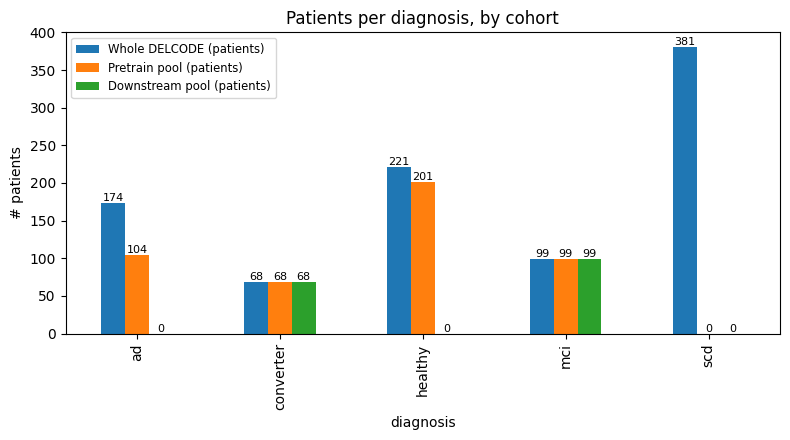

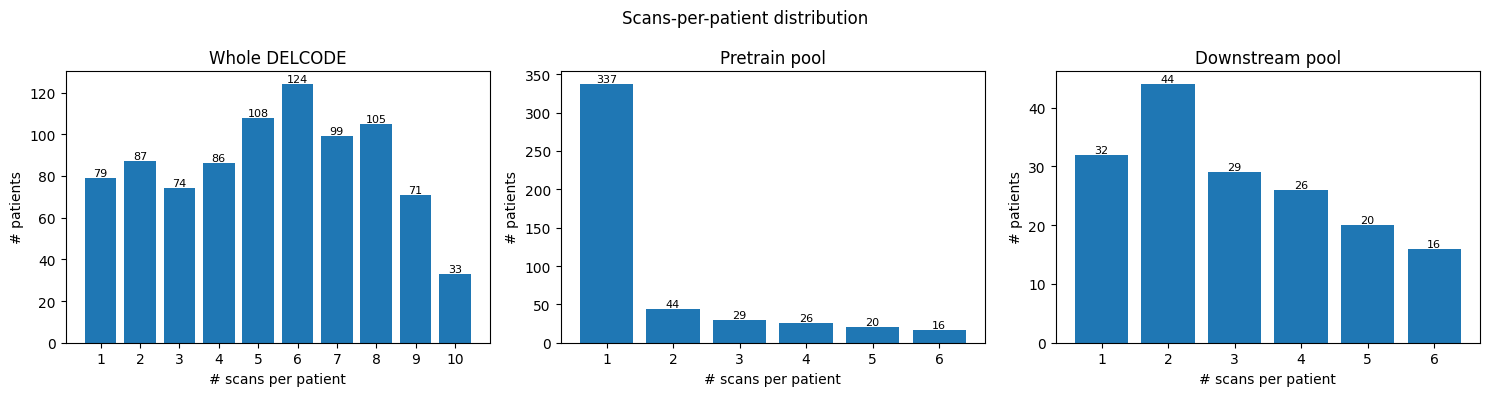

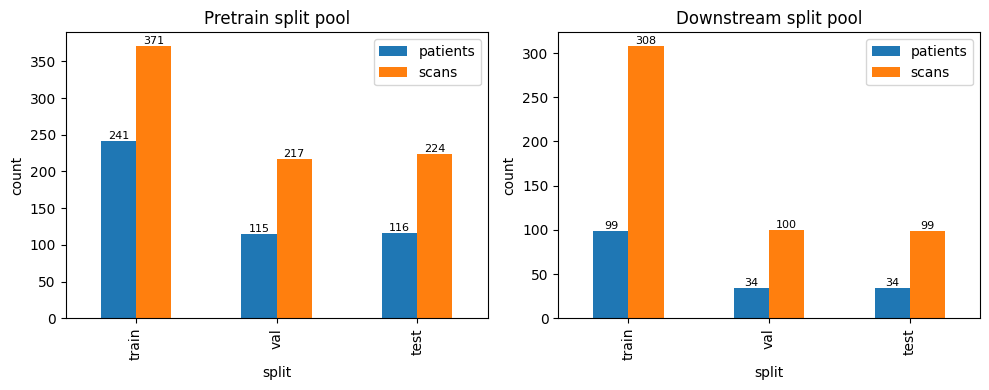

In [15]:
import matplotlib.pyplot as plt

# --- Plot 1: patients per diagnosis, grouped bar across cohorts ---
patient_cols = [c for c in diagnosis_table.columns if c.endswith('(patients)')]
plot_df = diagnosis_table[patient_cols].sort_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df.plot(kind='bar', ax=ax)
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
ax.set_title('Patients per diagnosis, by cohort')
ax.set_xlabel('diagnosis')
ax.set_ylabel('# patients')
ax.legend(title=None, fontsize='small')
fig.tight_layout()
plt.show()

# --- Plot 2: scans-per-patient distribution, one panel per cohort ---
cohort_dists = [
    ('Whole DELCODE', whole_stats['scans_per_patient']),
    ('Pretrain pool', pretrain_stats['scans_per_patient']),
]
if downstream_stats is not None:
    cohort_dists.append(('Downstream pool', downstream_stats['scans_per_patient']))

fig, axes = plt.subplots(1, len(cohort_dists), figsize=(5 * len(cohort_dists), 4), sharey=False)
if len(cohort_dists) == 1:
    axes = [axes]
for ax, (title, series) in zip(axes, cohort_dists):
    counts = series.value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values)
    ax.bar_label(bars, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('# scans per patient')
    ax.set_ylabel('# patients')
fig.suptitle('Scans-per-patient distribution')
fig.tight_layout()
plt.show()

# --- Plot 3: per-split patients & scans, pretrain vs downstream ---
split_tables = [('Pretrain', pretrain_stats['per_split'])]
if downstream_stats is not None:
    split_tables.append(('Downstream', downstream_stats['per_split']))

fig, axes = plt.subplots(1, len(split_tables), figsize=(5 * len(split_tables), 4), sharey=False)
if len(split_tables) == 1:
    axes = [axes]
for ax, (title, per_split) in zip(axes, split_tables):
    rows = per_split.drop(index='total')
    rows[['patients', 'scans']].plot(kind='bar', ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)
    ax.set_title(f'{title} split pool')
    ax.set_xlabel('split')
    ax.set_ylabel('count')
fig.tight_layout()
plt.show()

### F. Why the pretrain pool's "Pretrain pool" panel above is dominated by `n_scans = 1`

`n_scans` in the pretrain split CSVs is computed from the actual `.npz` matrix files on disk
(`_count_scans` in `DATA/src/splitting/create_pretrain_data_splits.py`), not from the number
of clinical visit rows in `cohorts.csv`. The two diverge by design:

- **`ad` / `healthy`** — GAAE pretraining treats these as **static / cross-sectional**: only the
  baseline scan (`ses-01_M0`) was ever turned into a connectivity matrix, even though `cohorts.csv`
  may list several later clinical visits for the same patient. So `n_scans = 1` for every single
  `ad`/`healthy` patient — that's not a stale or wrong number, there is genuinely only one matrix
  file for them.
- **`mci` / `converter`** — these are the longitudinal/conversion-relevant classes, so every
  follow-up scan was processed into its own matrix. `n_scans` for these patients reflects the real
  multi-visit trajectory (mean ≈ 2.8 for `mci`, ≈ 3.4 for `converter`).

So in the "Pretrain pool" panel of plot E2, the `n_scans = 1` bar is exactly
`n(ad) + n(healthy) + n(mci with 1 scan) + n(converter with 1 scan)` — not a measurement error.
The table below breaks that bar down by diagnosis.

Pretrain pool — patients per (diagnosis, n_scans):


n_scans,1,2,3,4,5,6
diagnosis,,,,,,
healthy,201,0,0,0,0,0
ad,104,0,0,0,0,0
mci,27,27,14,14,7,10
converter,5,17,15,12,13,6
TOTAL,337,44,29,26,20,16


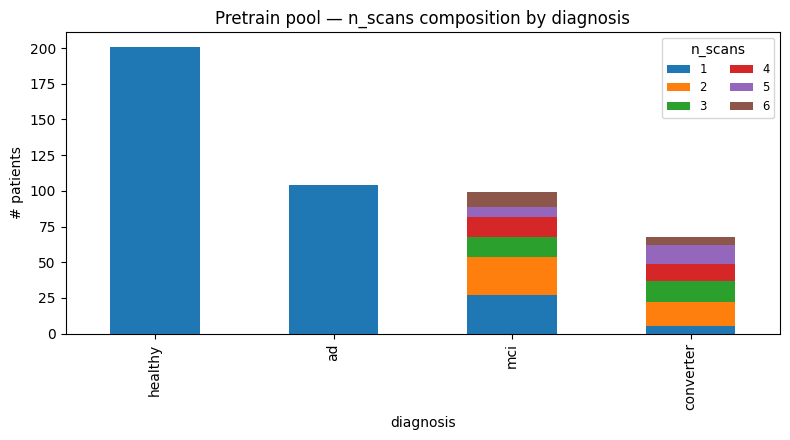

In [16]:
# Pretrain pool: patients per (diagnosis, n_scans) — explains why n_scans=1 dominates.
pretrain_breakdown = (
    pretrain_stats['pool']
    .groupby(['diagnosis', 'n_scans'])
    .size()
    .unstack(fill_value=0)
    .reindex(['healthy', 'ad', 'mci', 'converter'])
)
pretrain_breakdown.loc['TOTAL'] = pretrain_breakdown.sum()
print('Pretrain pool — patients per (diagnosis, n_scans):')
display(pretrain_breakdown)

fig, ax = plt.subplots(figsize=(8, 4.5))
pretrain_breakdown.drop(index='TOTAL').plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Pretrain pool — n_scans composition by diagnosis')
ax.set_xlabel('diagnosis')
ax.set_ylabel('# patients')
ax.legend(title='n_scans', fontsize='small', ncol=2)
fig.tight_layout()
plt.show()

Downstream pool — patients per (diagnosis, n_scans):


n_scans,1,2,3,4,5,6
diagnosis,,,,,,
mci,27,27,14,14,7,10
converter,5,17,15,12,13,6
TOTAL,32,44,29,26,20,16


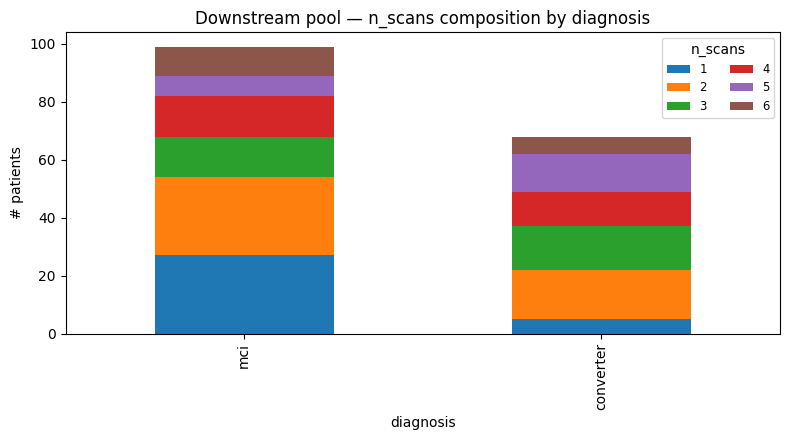

In [17]:
# Downstream pool: patients per (diagnosis, n_scans) — mci/converter only, all longitudinal.
if downstream_stats is not None:
    downstream_breakdown = (
        downstream_stats['pool']
        .groupby(['diagnosis', 'n_scans'])
        .size()
        .unstack(fill_value=0)
        .reindex(['mci', 'converter'])
    )
    downstream_breakdown.loc['TOTAL'] = downstream_breakdown.sum()
    print('Downstream pool — patients per (diagnosis, n_scans):')
    display(downstream_breakdown)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    downstream_breakdown.drop(index='TOTAL').plot(kind='bar', stacked=True, ax=ax)
    ax.set_title('Downstream pool — n_scans composition by diagnosis')
    ax.set_xlabel('diagnosis')
    ax.set_ylabel('# patients')
    ax.legend(title='n_scans', fontsize='small', ncol=2)
    fig.tight_layout()
    plt.show()
else:
    print('Downstream splits not present at expected paths — skipping')